In [90]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [91]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'chain_no_if'
program = 'chain'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files = glob(pattern, recursive=True)
dfs = []
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs.append(df[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results = []
for i in range(len(dfs[0])):
    values = [df['best_fitness'].iloc[i] for df in dfs]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df = pd.DataFrame(results)
print(results_df)


            mean         std      median         q25         q75
0    -596.603545  335.784571 -596.603545 -764.495830 -428.711260
1    -197.109410    1.613034 -197.109410 -197.915927 -196.302893
2    -183.418183    6.489998 -183.418183 -186.663182 -180.173184
3    -174.702941    2.225244 -174.702941 -175.815563 -173.590319
4    -159.386633    2.578566 -159.386633 -160.675916 -158.097350
...          ...         ...         ...         ...         ...
1496  -77.584973    4.576578  -77.584973  -79.873262  -75.296684
1497  -77.584973    4.576578  -77.584973  -79.873262  -75.296684
1498  -77.584973    4.576578  -77.584973  -79.873262  -75.296684
1499  -77.584970    4.576581  -77.584970  -79.873261  -75.296680
1500  -77.584970    4.576581  -77.584970  -79.873261  -75.296680

[1501 rows x 5 columns]


In [92]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
#real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

real_dataset_file = f'fitness/datasets/{program}.csv'
real_dataset = np.loadtxt(real_dataset_file, delimiter=',')

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)

likelihood_intervened = 0
likelihood_base_intervened = 0
print(f'Likelihood of real program: {likelihood}')
print(f'\nLikelihood of baseline program: {likelihood_base}')
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood_intervened += interventional_likelihood
    likelihood_base_intervened += interventional_likelihood_base


likelihood = likelihood + likelihood_intervened
likelihood_base = likelihood_base + likelihood_base_intervened
print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Likelihood of real program: -7.413840944804516

Likelihood of baseline program: -11.661491150058803
Total likelihood of real program: -56.622844354516346
Total likelihood of baseline program: -100.37926462703412


In [93]:
# between all the files, find the one with best likelihood and print the corresponding program
best_likelihood = -np.inf
best_program = None
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    max_likelihood = df['best_fitness'].max()
    if max_likelihood > best_likelihood:
        best_likelihood = max_likelihood
        best_program = file 
print(f'Best likelihood: {best_likelihood}')
#print(f'Best program file: {best_program}')

#in the folder where the best stats.tsv file is, print the content of the best.txt file
best_program_file = best_program.replace('stats.tsv', 'best.txt')
with open(best_program_file, 'r') as f:
    best_program_content = f.read()
print(f'Best program content:\n{best_program_content}')

Best likelihood: -73.00838973577089
Best program content:
Generation:
1500

Phenotype:
3
V1 = uniform([-0.5e0, 2.5e1], 2);
V2 = -1.7e0;
V2 = V2 + uniform([+7.9e0, 7.5e0], 2);
V3 = -V1 * -V1;
V3 = V3 + gm([4.9e0, -1.0e0, 9.9e0], [3.9e0, -1.6e0, 8.5e0]);

Pre-processed Program
:T = uniform([-0.500000, 24.500000], 2);F = 0;F = F - 1.7;F = F + uniform([7.900000, 15.400000], 2);TEMP0 = T * T;P = TEMP0;P = P + gm([0.556818, 0.443182], [-1, -1.6], [9.9, 8.5]);Genotype:
[88, 254, 48, 271, 437, 251, 1, 180, 395, 222, 196, 212, 385, 299, 296, 434, 154, 463, 116, 243, 371, 177, 136, 305, 288, 203, 498, 167, 269, 274, 353, 207, 185, 4, 276, 248, 193, 352, 82, 149, 370, 300, 11, 368, 50, 187, 77, 18, 474, 439, 142, 430, 365, 301, 480, 126, 44, 319, 359, 144, 50, 40, 243, 379, 6, 454, 199, 391, 476, 250, 484, 348, 75, 248, 286, 75, 219, 436, 419, 28, 400, 101, 400, 241, 382, 89, 285, 145, 92, 243, 93, 135, 452, 357, 85, 210, 76, 381, 423, 98]
Tree:
None
Fitness on 5000 data:
-73.00838973577089

Fitn

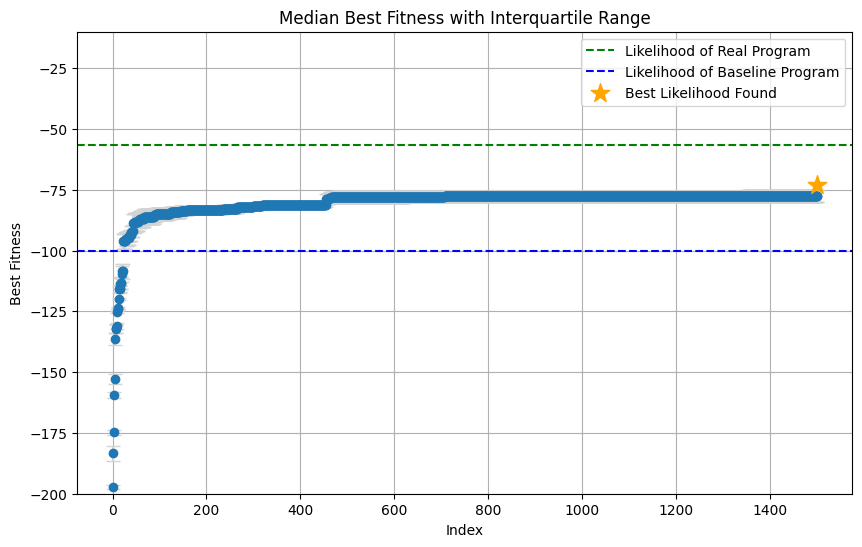

In [96]:
# Plot results_df median with error bars for q25 and q75
plt.figure(figsize=(10, 6))
plt.errorbar(results_df.index, results_df['median'], yerr=[results_df['median'] - results_df['q25'], results_df['q75'] - results_df['median']], fmt='o', ecolor='lightgray', capsize=5)
plt.title('Median Best Fitness with Interquartile Range')
plt.xlabel('Index')
plt.ylabel('Best Fitness')
plt.ylim(-200, -10)

# Add a horizontal line for the likelihood of the real program and the baseline program
plt.axhline(y=likelihood, color='g', linestyle='--', label='Likelihood of Real Program')
plt.axhline(y=likelihood_base, color='b', linestyle='--', label='Likelihood of Baseline Program')

# Add a point for the best likelihood found in the files with the shape of a star and color orange
plt.scatter(len(results_df)-1, best_likelihood, color='orange', label='Best Likelihood Found', zorder=5, marker='*', s=200)

plt.legend()

plt.grid()
plt.show()